In [ ]:
# Run the line below once to install the UCI ML Repository library
!pip install ucimlrepo

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib
from sklearn.metrics import accuracy_score, classification_report
from ucimlrepo import fetch_ucirepo
from IPython.display import display

In [ ]:
# -------------------------------------
# 1. Load the Dataset from UCI ML Repo
# -------------------------------------

# Fetch dataset
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697)

# Extract features and target variables
X = predict_students_dropout_and_academic_success.data.features
y = predict_students_dropout_and_academic_success.data.targets

# Clean column names (remove any extra spaces or special characters)
X.columns = X.columns.str.strip()

# Display metadata
print(predict_students_dropout_and_academic_success.metadata)

# Display variable information
print(predict_students_dropout_and_academic_success.variables)

{'uci_id': 697, 'name': "Predict Students' Dropout and Academic Success", 'repository_url': 'https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success', 'data_url': 'https://archive.ics.uci.edu/static/public/697/data.csv', 'abstract': "A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies.\nThe dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters. \nThe data is used to build classification models to predict students' dropout and academic sucess. The problem is formulated as a three category classification task, in which there is a strong imbalance towards one of the classes.", 'area': 'Social Sc

   Marital Status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   
5               2                39                  1    9991   
6               1                 1                  1    9500   
7               1                18                  4    9254   
8               1                 1                  3    9238   
9               1                 1                  1    9238   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                

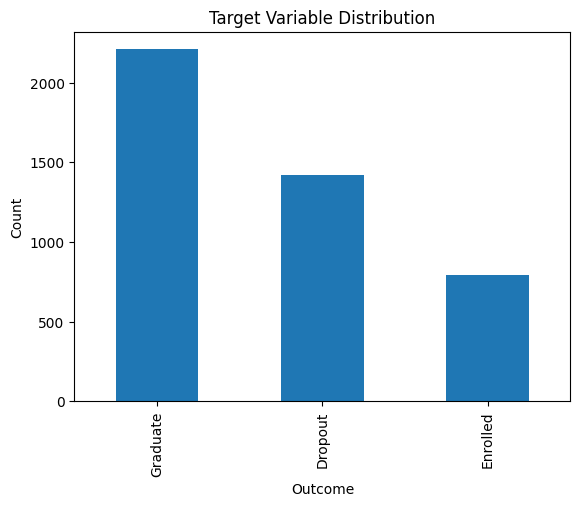

In [ ]:
# -----------------------------------
# 2. Exploratory Data Analysis (EDA)
# -----------------------------------

# Check head of dataset
print(X.head(10))

# Visualize the target variable
pd.Series(y['Target']).value_counts().plot(kind='bar', title='Target Variable Distribution') # Convert y to Pandas Series by selecting the 'Target' column
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

In [ ]:
# ----------------------
# 3. Data Preprocessing
# ----------------------

# Encode target labels
label_mapping = {'Graduate': 1, 'Dropout': 0, 'Enrolled': -1}  # Using -1 for unseen data
y.loc[:, 'Target'] = y['Target'].map(label_mapping)

# Identify categorical columns to encode
categorical_columns = [
    "Marital status", "Application mode", "Course", "Daytime/evening attendance",
    "Previous qualification", "Nacionality", "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", "Displaced", "Educational special needs",
    "Debtor", "Tuition fees up to date", "Gender", "Scholarship holder", "International"
]

# Encode categorical variables safely
X_encoded = X.copy()  # Creating a copy to avoid warnings
for col in categorical_columns:
    if col in X_encoded.columns:
        X_encoded.loc[:, col] = LabelEncoder().fit_transform(X_encoded[col])

# Split data into training (Graduated + Dropout) and unseen test (Enrolled)
X_train = X_encoded[y['Target'] != -1].copy()  # Take only Graduated & Dropout
y_train = y[y['Target'] != -1].copy()  # Corresponding labels

X_unseen = X_encoded[y['Target'] == -1].copy()  # Unseen "Enrolled" students
y_unseen = y[y['Target'] == -1].copy()  # Their labels (for later evaluation)

# Display the shapes of the subsets
print(f"Training Features Shape: {X_train.shape}")
print(f"Training Labels Shape: {y_train.shape}")
print(f"Unseen Features Shape: {X_unseen.shape}")
print(f"Unseen Labels Shape: {y_unseen.shape}")


Training Features Shape: (3630, 36)
Training Labels Shape: (3630, 1)
Unseen Features Shape: (794, 36)
Unseen Labels Shape: (794, 1)


In [ ]:
# ----------------------------
# 4. Train and Evaluate Models
# ----------------------------

# Split train data into train and validation sets
X_train_final, X_test, y_train_final, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Ensure target labels are correctly formatted
y_train_final = y_train_final['Target'].to_numpy().astype(int)
y_test = y_test['Target'].to_numpy().astype(int)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for later use
joblib.dump(scaler, "scaler.pkl")

# Define classification models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier()
}

# Train, evaluate, and save models
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train_final)  # Train model
    y_pred = model.predict(X_test_scaled)  # Predict on test set
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    # ✅ Save the trained model
    model_filename = f"{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(model, model_filename)

    print(f"\n Model '{name}' saved as {model_filename}")
    print(f"Accuracy of {name}: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))

# Display accuracy results
print("\n Model Performance:")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")



 Model 'Logistic Regression' saved as logistic_regression.pkl
Accuracy of Logistic Regression: 0.9160
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       277
           1       0.91      0.96      0.93       449

    accuracy                           0.92       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.92      0.92      0.92       726


 Model 'Random Forest' saved as random_forest.pkl
Accuracy of Random Forest: 0.9022
              precision    recall  f1-score   support

           0       0.92      0.82      0.86       277
           1       0.89      0.96      0.92       449

    accuracy                           0.90       726
   macro avg       0.91      0.89      0.89       726
weighted avg       0.90      0.90      0.90       726


 Model 'XGBoost' saved as xgboost.pkl
Accuracy of XGBoost: 0.9036
              precision    recall  f1-score   support

           0       0.90      0.84   

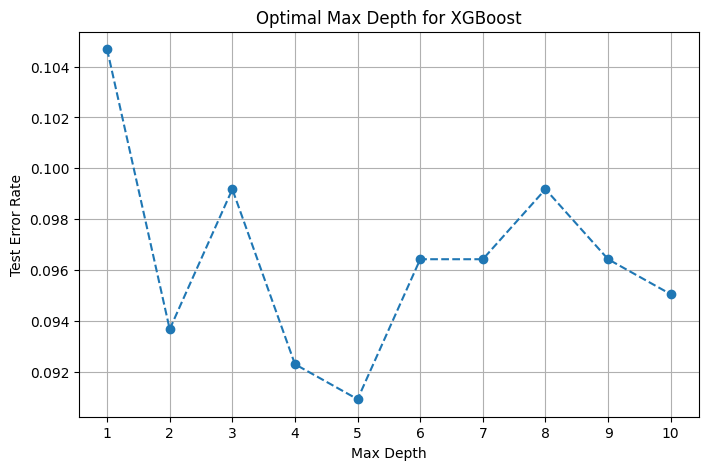


 Best max_depth: 5


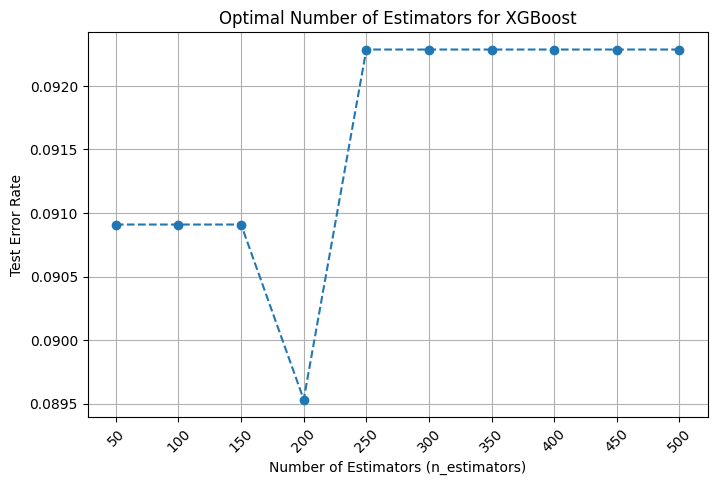


 Best n_estimators: 200


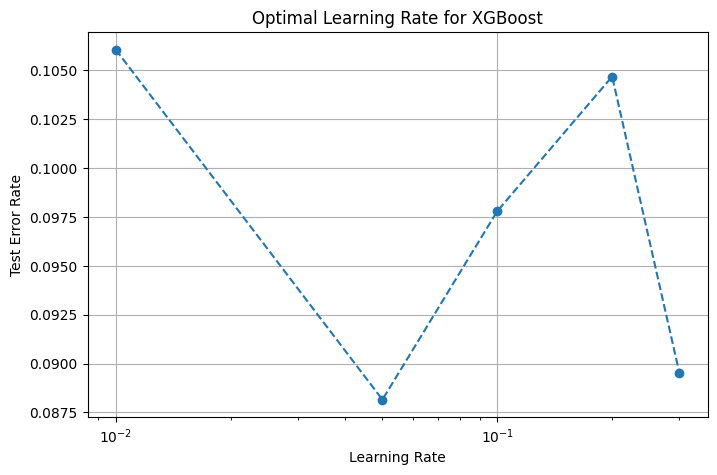


 Best learning_rate: 0.05

 Final Optimized XGBoost Accuracy: 0.9118


In [ ]:
# ----------------------------
# 5. Improve XGBoost Accuracy
# ----------------------------

# 1. Determine Best max_depth

xgb_test_errors = []
max_depth_range = range(1, 11)  # Testing depths from 1 to 10

for depth in max_depth_range:
    xgb_model = XGBClassifier(n_estimators=100, max_depth=depth, eval_metric="logloss")
    xgb_model.fit(X_train_scaled, y_train_final)
    y_pred = xgb_model.predict(X_test_scaled)
    error = 1 - accuracy_score(y_test, y_pred)
    xgb_test_errors.append(error)

# Plot results
plt.figure(figsize=(8,5))
plt.plot(max_depth_range, xgb_test_errors, marker='o', linestyle='dashed')
plt.xlabel("Max Depth")
plt.ylabel("Test Error Rate")
plt.title("Optimal Max Depth for XGBoost")
plt.xticks(max_depth_range)
plt.grid()
plt.show()

# Select best depth (lowest error)
best_max_depth = max_depth_range[np.argmin(xgb_test_errors)]
print(f"\n Best max_depth: {best_max_depth}")

# 2. Determine Best n_estimators

n_estimators_range = range(50, 550, 50)  # Testing in increments of 50
xgb_test_errors = []

for n in n_estimators_range:
    xgb_model = XGBClassifier(n_estimators=n, max_depth=best_max_depth, eval_metric="logloss")
    xgb_model.fit(X_train_scaled, y_train_final)
    y_pred = xgb_model.predict(X_test_scaled)
    error = 1 - accuracy_score(y_test, y_pred)
    xgb_test_errors.append(error)

# Plot results
plt.figure(figsize=(8,5))
plt.plot(n_estimators_range, xgb_test_errors, marker='o', linestyle='dashed')
plt.xlabel("Number of Estimators (n_estimators)")
plt.ylabel("Test Error Rate")
plt.title("Optimal Number of Estimators for XGBoost")
plt.xticks(n_estimators_range, rotation=45)
plt.grid()
plt.show()

# Select best n_estimators
best_n_estimators = n_estimators_range[np.argmin(xgb_test_errors)]
print(f"\n Best n_estimators: {best_n_estimators}")

# 3. Determine Best Learning Rate

learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3]
xgb_test_errors = []

for lr in learning_rates:
    xgb_model = XGBClassifier(n_estimators=best_n_estimators, max_depth=best_max_depth, learning_rate=lr, eval_metric="logloss")
    xgb_model.fit(X_train_scaled, y_train_final)
    y_pred = xgb_model.predict(X_test_scaled)
    error = 1 - accuracy_score(y_test, y_pred)
    xgb_test_errors.append(error)

# Plot results
plt.figure(figsize=(8,5))
plt.plot(learning_rates, xgb_test_errors, marker='o', linestyle='dashed')
plt.xlabel("Learning Rate")
plt.ylabel("Test Error Rate")
plt.title("Optimal Learning Rate for XGBoost")
plt.xscale("log")
plt.grid()
plt.show()

# Select best learning rate
best_learning_rate = learning_rates[np.argmin(xgb_test_errors)]
print(f"\n Best learning_rate: {best_learning_rate}")


# Final XGBoost Model with Optimized Hyperparameters
best_xgb_model = XGBClassifier(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    learning_rate=best_learning_rate,
    eval_metric="logloss"
)

best_xgb_model.fit(X_train_scaled, y_train_final)
y_pred_final = best_xgb_model.predict(X_test_scaled)

final_xgb_accuracy = accuracy_score(y_test, y_pred_final)
print(f"\n Final Optimized XGBoost Accuracy: {final_xgb_accuracy:.4f}")


In [ ]:
# ----------------------------
# 6. Predict Outcomes for Enrolled Students
# ----------------------------

# Load trained models
scaler = joblib.load("scaler.pkl")  # Load saved scaler
logistic_model = joblib.load("logistic_regression.pkl")  # Load trained Logistic Regression model
best_xgb_model = joblib.load("xgboost.pkl")  # Load trained XGBoost model

# Scale `X_unseen` using the same scaler
X_unseen_scaled = scaler.transform(X_unseen)

# Predict using Logistic Regression
y_pred_logistic = logistic_model.predict(X_unseen_scaled)

# Predict using XGBoost
y_pred_xgb = best_xgb_model.predict(X_unseen_scaled)

# Convert predictions back to labels
label_mapping_reverse = {1: 'Graduated', 0: 'Dropout'}

y_pred_logistic_labels = [label_mapping_reverse[pred] for pred in y_pred_logistic]
y_pred_xgb_labels = [label_mapping_reverse[pred] for pred in y_pred_xgb]

# Create a DataFrame to compare predictions
comparison_df = pd.DataFrame({
    "Student_Index": X_unseen.index,  # Keep track of students
    "Logistic_Prediction": y_pred_logistic_labels,
    "XGBoost_Prediction": y_pred_xgb_labels
})

# Display the DataFrame
display(comparison_df.head(20))  # Show first 20 rows

# Calculate differences
diff_count = (comparison_df["Logistic_Prediction"] != comparison_df["XGBoost_Prediction"]).sum()
total_predictions = len(comparison_df)
diff_percentage = (diff_count / total_predictions) * 100

# Print summary of differences
print(f"\n {diff_count} out of {total_predictions} students ({diff_percentage:.2f}%) have different predictions between Logistic Regression and XGBoost.")



,Student_Index,Logistic_Prediction,XGBoost_Prediction
0,16,Dropout,Dropout
1,19,Graduated,Graduated
2,21,Graduated,Graduated
3,25,Graduated,Graduated
4,27,Graduated,Graduated
5,29,Graduated,Graduated
6,30,Graduated,Graduated
7,32,Dropout,Dropout
8,45,Dropout,Dropout
9,51,Graduated,Graduated



 124 out of 794 students (15.62%) have different predictions between Logistic Regression and XGBoost.


In [ ]:
# ----------------------------
# 7. Train Final XGBoost Model & Predict Enrolled Students' Success
# ----------------------------

# Retrain XGBoost on the full dataset (Graduated + Dropout)
final_xgb_model = XGBClassifier(
    n_estimators=200,  # Best found from tuning
    max_depth=5,       # Best found from tuning
    learning_rate=0.05, # Best found from tuning
    eval_metric="logloss"
)

final_xgb_model.fit(X_train_scaled, y_train_final)  # Train on full dataset

# Predict outcomes for Enrolled students
y_pred_unseen = final_xgb_model.predict(X_unseen_scaled)

# Convert predictions back to labels
label_mapping_reverse = {1: 'Graduated', 0: 'Dropout'}
y_pred_unseen_labels = [label_mapping_reverse[pred] for pred in y_pred_unseen]

# Create a DataFrame for final predictions
final_predictions_df = pd.DataFrame({
    "Student_Index": X_unseen.index,
    "Predicted_Outcome": y_pred_unseen_labels
})

# Display the predictions
display(final_predictions_df.head(20))  # Show first 20 rows


,Student_Index,Predicted_Outcome
0,16,Dropout
1,19,Graduated
2,21,Graduated
3,25,Graduated
4,27,Graduated
5,29,Graduated
6,30,Graduated
7,32,Dropout
8,45,Dropout
9,51,Graduated


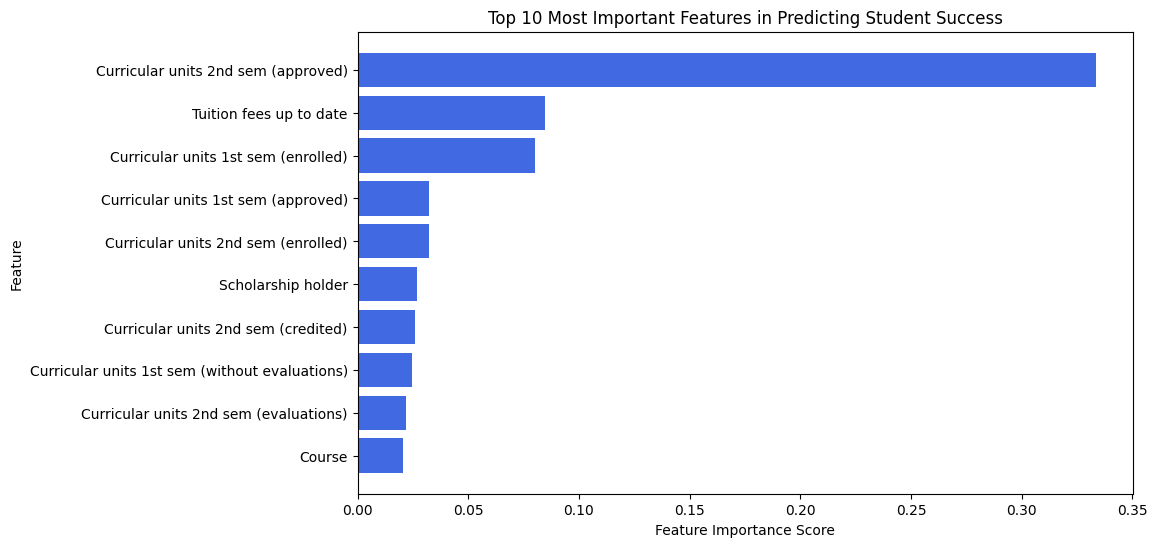

,Feature,Importance
30,Curricular units 2nd sem (approved),0.333348
16,Tuition fees up to date,0.084707
22,Curricular units 1st sem (enrolled),0.080376
24,Curricular units 1st sem (approved),0.032218
28,Curricular units 2nd sem (enrolled),0.032183
18,Scholarship holder,0.026723
27,Curricular units 2nd sem (credited),0.025917
26,Curricular units 1st sem (without evaluations),0.024714
29,Curricular units 2nd sem (evaluations),0.021892
3,Course,0.020549


In [ ]:
# ----------------------------
# 8. Analyze Feature Importance
# ----------------------------

# Get feature importance from XGBoost
feature_importance = final_xgb_model.feature_importances_

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance
})

# Sort features by importance
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"][:10], importance_df["Importance"][:10], color="royalblue")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features in Predicting Student Success")
plt.gca().invert_yaxis()  # Invert axis for better readability
plt.show()

# Display top 10 important features
display(importance_df.head(10))
